# Setup and Dependecies

In [64]:
%pip install xgboost lightgbm optuna

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [65]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
import pickle as pkl
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import optuna
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

SEED = 50303776

# Load and Preview

In [66]:
df = pd.read_csv("Heart Attack Data Set.csv")

In [67]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [69]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [70]:
df['target'].value_counts()

1    165
0    138
Name: target, dtype: int64

No missing value, unsensible value, nor data type mismatch found.

In [71]:
df.duplicated().sum()

1

To prevent the duplicated values to enter both train and test when splittng (say A and B are the same, A enters train, B enters test), the duplicate will be dropped now.

In [72]:
df = df.drop_duplicates()

# Distribution check

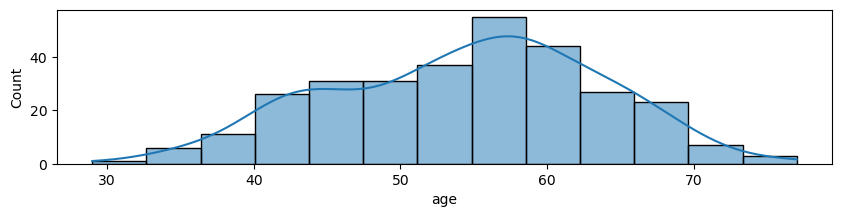

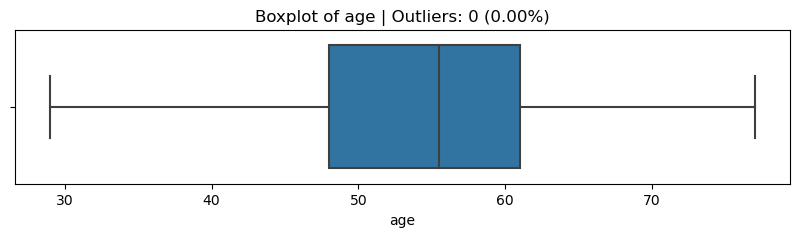

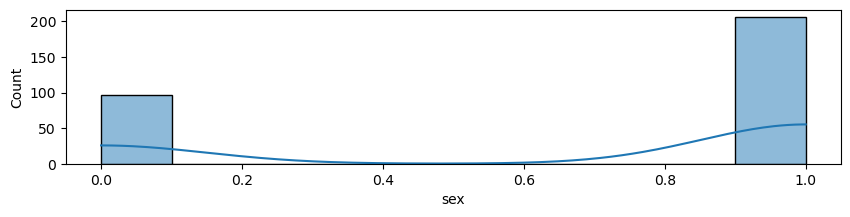

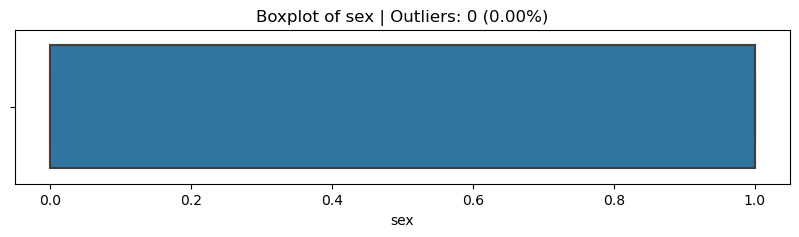

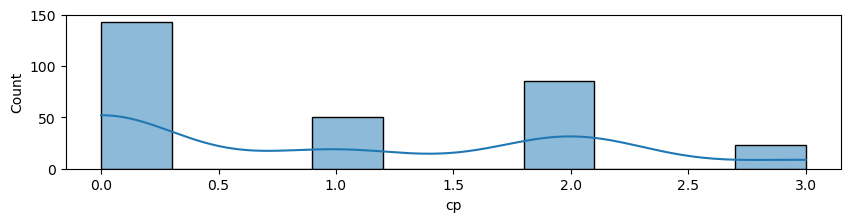

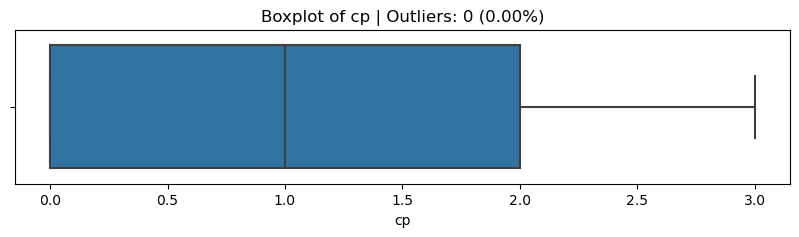

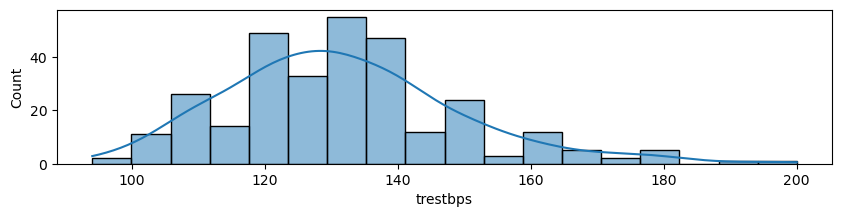

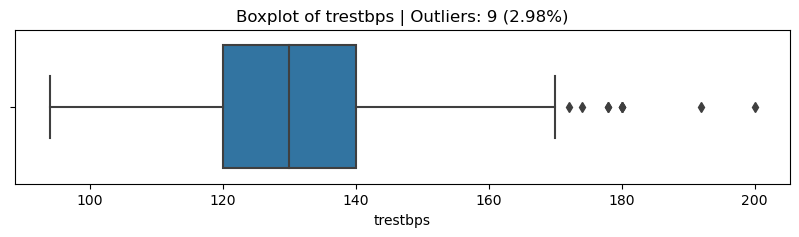

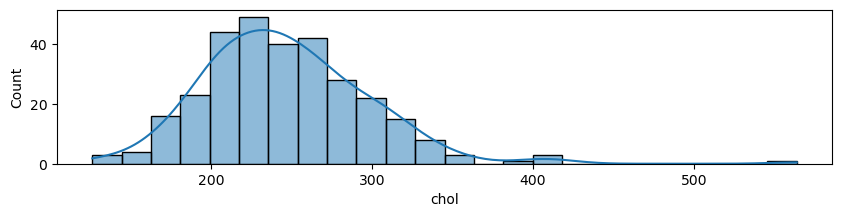

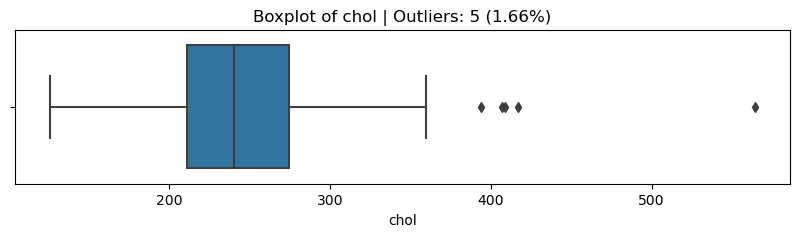

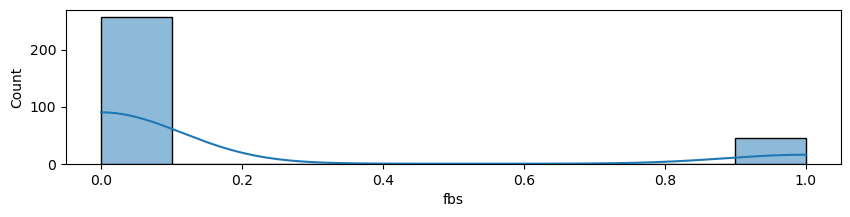

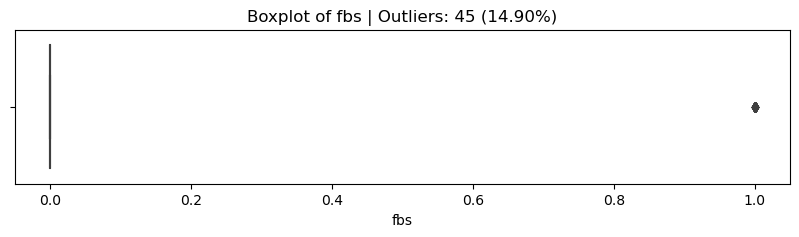

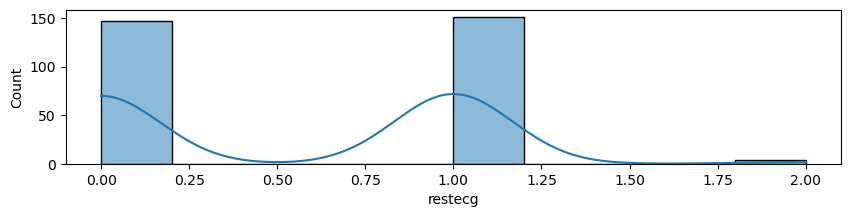

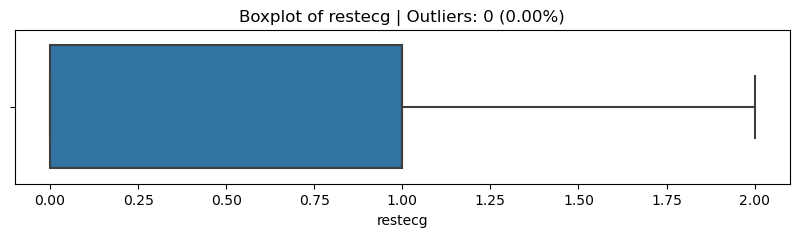

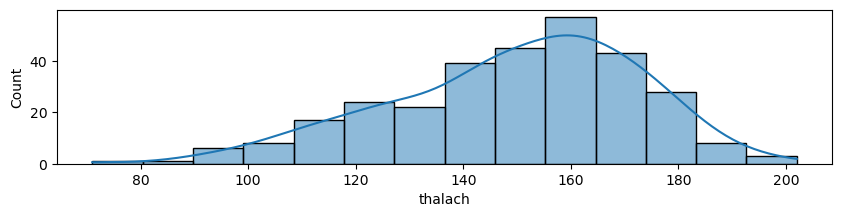

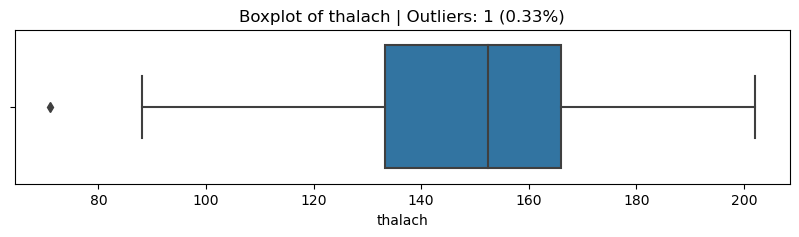

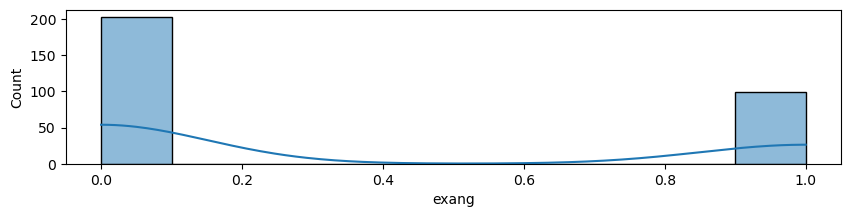

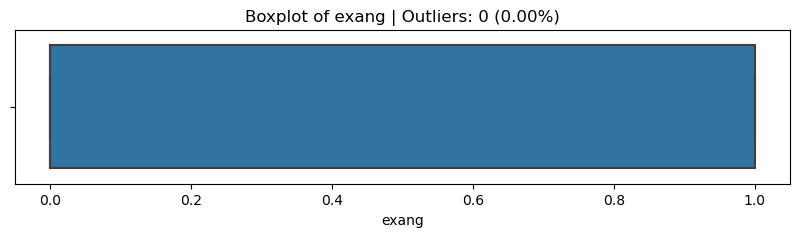

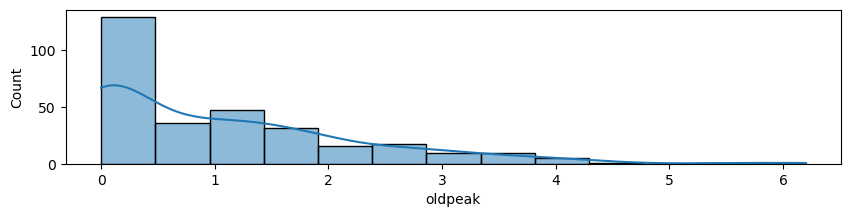

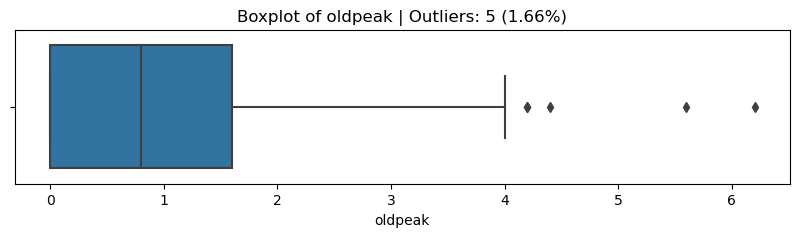

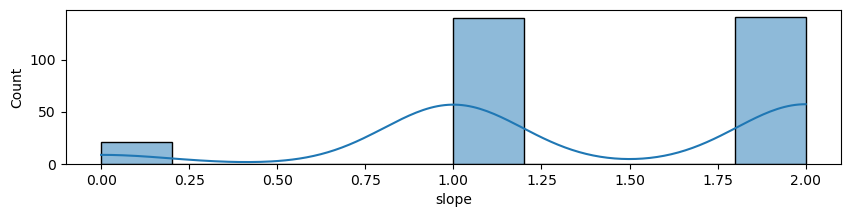

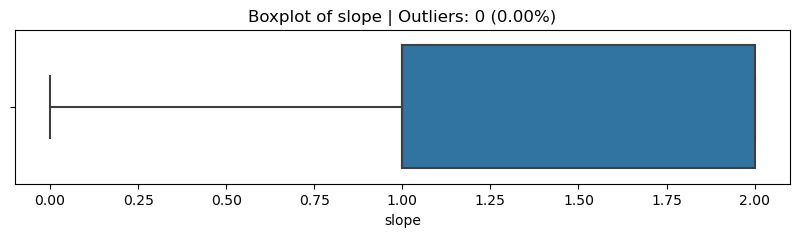

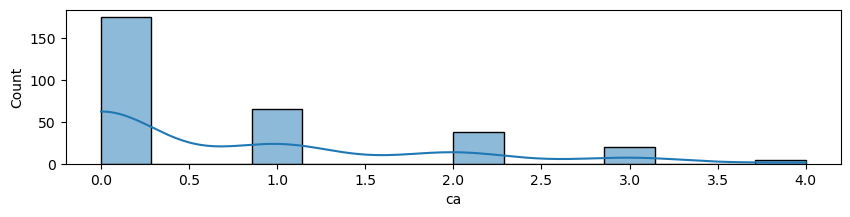

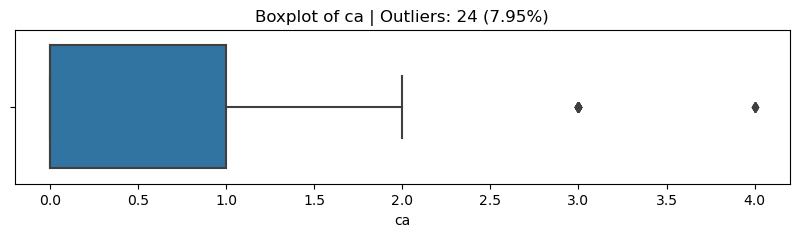

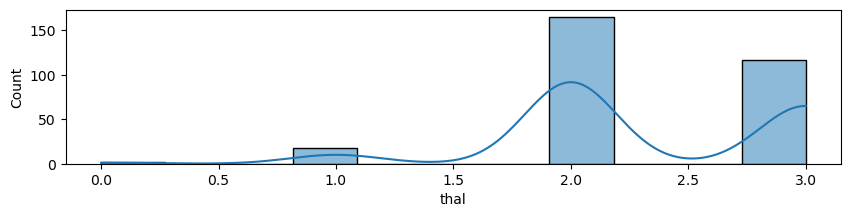

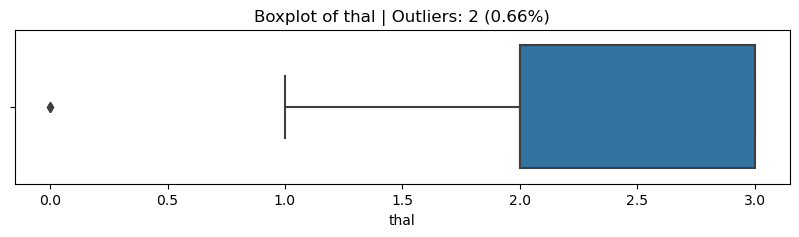

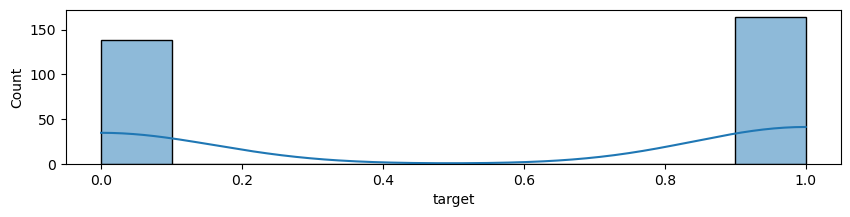

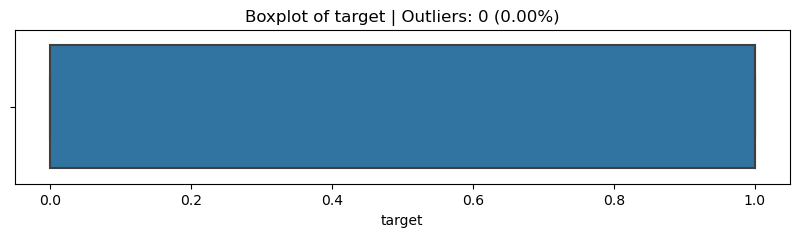

In [73]:
for c in  df.select_dtypes(include="number").columns:
    plt.figure(figsize=(10,2))
    sns.histplot(data=df, x=c, kde=True)
    plt.show()

    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[c] < lower_bound) | (df[c] > upper_bound)][c]

    outlier_count = outliers.shape[0]
    total_count = df[c].shape[0]
    outlier_percentage = (outlier_count / total_count) * 100

    plt.figure(figsize=(10,2))
    sns.boxplot(data=df, x=c)

    plt.title(
        f"Boxplot of {c} | Outliers: {outlier_count} "
        f"({outlier_percentage:.2f}%)"
    )

    plt.show()

No irregularities found, those who have sparse distribution are all discrete feature which is expected. Some continous feature might be skewed but not significantly and have minor outlier count, so no transform aside from standard scaling will be done. This also suggest that in building the pipeline, filling missing value with mean is unwise since there are skewed columns. Later on, median will be used. 

# Multicollinearity Check

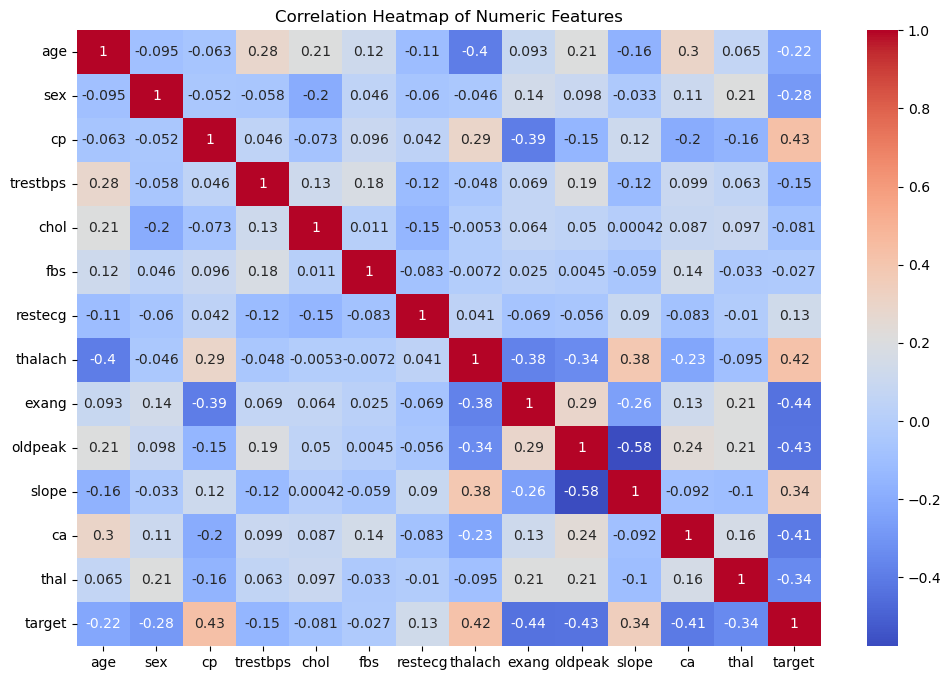

In [74]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

No substantial correlation between features

# Splitting

In [75]:
X = df.drop('target', axis=1)
y = df['target']

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = SEED, stratify=y)

# Scale

In [77]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train

In [78]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

## Logistic Regression

In [79]:
def objective_logreg(trial):

    params = {
        "C": trial.suggest_float("C", 1e-4, 100, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l2"]),
        "solver": "lbfgs",
        "max_iter": 1000,
        "random_state": SEED,
    }

    model = LogisticRegression(**params)

    model.fit(X_train, y_train)

    preds = model.predict_proba(X_valid)[:, 1]
    fpr, tpr, _ = roc_curve(y_valid, preds)
    score = auc(fpr, tpr)

    return score


study_logreg = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_logreg.optimize(objective_logreg, n_trials=50)

print("Best score:", study_logreg.best_value)
print("Best params:", study_logreg.best_params)


[I 2026-02-17 14:28:11,422] A new study created in memory with name: no-name-d1fbe392-2f86-476e-9657-7d5658d4d9ef
[I 2026-02-17 14:28:11,441] Trial 0 finished with value: 0.8484848484848485 and parameters: {'C': 0.03450783878930054, 'penalty': 'l2'}. Best is trial 0 with value: 0.8484848484848485.
[I 2026-02-17 14:28:11,450] Trial 1 finished with value: 0.8535353535353536 and parameters: {'C': 16.80099411563001, 'penalty': 'l2'}. Best is trial 1 with value: 0.8535353535353536.
[I 2026-02-17 14:28:11,460] Trial 2 finished with value: 0.8518518518518519 and parameters: {'C': 0.9852621745356318, 'penalty': 'l2'}. Best is trial 1 with value: 0.8535353535353536.
[I 2026-02-17 14:28:11,468] Trial 3 finished with value: 0.8552188552188552 and parameters: {'C': 0.00022023650300313018, 'penalty': 'l2'}. Best is trial 3 with value: 0.8552188552188552.
[I 2026-02-17 14:28:11,475] Trial 4 finished with value: 0.8535353535353536 and parameters: {'C': 62.94385722160401, 'penalty': 'l2'}. Best is tri

Best score: 0.8585858585858586
Best params: {'C': 0.0021241863124102614, 'penalty': 'l2'}


## Random Forest

In [80]:
def objective_rf(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": SEED,
        "n_jobs": -1,
    }

    model = RandomForestClassifier(**params)

    model.fit(X_train, y_train)

    preds = model.predict_proba(X_valid)[:, 1]
    fpr, tpr, _ = roc_curve(y_valid, preds)
    score = auc(fpr, tpr)

    return score


study_rf = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=50)

print("Best score:", study_rf.best_value)
print("Best params:", study_rf.best_params)


[I 2026-02-17 14:28:12,170] A new study created in memory with name: no-name-2161740b-b3e5-49d2-9937-de025908613a
[I 2026-02-17 14:28:13,728] Trial 0 finished with value: 0.8333333333333333 and parameters: {'n_estimators': 750, 'max_depth': 18, 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.8333333333333333.
[I 2026-02-17 14:28:16,515] Trial 1 finished with value: 0.8518518518518519 and parameters: {'n_estimators': 1488, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 14, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8518518518518519.
[I 2026-02-17 14:28:18,776] Trial 2 finished with value: 0.8333333333333334 and parameters: {'n_estimators': 1093, 'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 11, 'max_features': None}. Best is trial 1 with value: 0.8518518518518519.
[I 2026-02-17 14:28:20,515] Trial 3 finished with value: 0.8552188552188552 and parameters: {'n_estimators': 829, 'max_depth': 17, 

Best score: 0.8552188552188552
Best params: {'n_estimators': 829, 'max_depth': 17, 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 'log2'}


## XGB

In [81]:
def objective_xgb(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "random_state": SEED,
        "verbosity": 0,

        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        "early_stopping_rounds": 100,
    }

    model_xgb = xgb.XGBClassifier(**params)

    model_xgb.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
    )


    preds = model_xgb.predict_proba(X_valid)[:, 1]
    fpr, tpr, _ = roc_curve(y_valid, preds)
    score = auc(fpr, tpr)

    return score

study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=50)

print("Best score:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)


[I 2026-02-17 14:29:56,121] A new study created in memory with name: no-name-91f69c7e-54e7-492b-9ce2-9f197e009e28
[I 2026-02-17 14:29:56,214] Trial 0 finished with value: 0.7904040404040404 and parameters: {'n_estimators': 961, 'max_depth': 11, 'learning_rate': 0.05824897229223468, 'subsample': 0.5285741085459315, 'colsample_bytree': 0.9832461127592133, 'gamma': 6.0015634373125915, 'reg_alpha': 5.950245733493455, 'reg_lambda': 8.163096493551535}. Best is trial 0 with value: 0.7904040404040404.
[I 2026-02-17 14:29:56,273] Trial 1 finished with value: 0.8484848484848484 and parameters: {'n_estimators': 1523, 'max_depth': 7, 'learning_rate': 0.06549590690257874, 'subsample': 0.9843036807634771, 'colsample_bytree': 0.9395489173457707, 'gamma': 4.0091907419864, 'reg_alpha': 0.015137052440261598, 'reg_lambda': 0.13396618055543502}. Best is trial 1 with value: 0.8484848484848484.
[I 2026-02-17 14:29:56,335] Trial 2 finished with value: 0.8375420875420875 and parameters: {'n_estimators': 1067,

Best score: 0.9023569023569024
Best params: {'n_estimators': 1705, 'max_depth': 6, 'learning_rate': 0.007958257832949378, 'subsample': 0.7667974327688833, 'colsample_bytree': 0.7994295062201283, 'gamma': 0.8610369210960772, 'reg_alpha': 1.1473381027038442e-08, 'reg_lambda': 8.265544053577707e-07}


## LGBM

In [82]:
def objective_lgbm(trial):

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": SEED,

        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 2000),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    model_lgbm = lgb.LGBMClassifier(**params)

    model_lgbm.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ],
    )

    preds = model_lgbm.predict_proba(X_valid)[:, 1]
    fpr, tpr, _ = roc_curve(y_valid, preds)
    score = auc(fpr, tpr)
    
    return score


study_lgbm = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(objective_lgbm, n_trials=50)

print("Best LGBM score:", study_lgbm.best_value)
print("Best LGBM params:", study_lgbm.best_params)

[I 2026-02-17 14:30:00,858] A new study created in memory with name: no-name-831d2ccc-9fd7-40fe-b469-3597392b6dd2
[I 2026-02-17 14:30:00,892] Trial 0 finished with value: 0.5 and parameters: {'num_leaves': 138, 'max_depth': 14, 'learning_rate': 0.05824897229223468, 'n_estimators': 302, 'min_child_samples': 97, 'subsample': 0.8000781718656296, 'colsample_bytree': 0.9874741612005731, 'reg_alpha': 8.163096493551535, 'reg_lambda': 0.04119688666972247}. Best is trial 0 with value: 0.5.
[I 2026-02-17 14:30:00,921] Trial 1 finished with value: 0.8619528619528619 and parameters: {'num_leaves': 134, 'max_depth': 12, 'learning_rate': 0.17813001543852724, 'n_estimators': 1783, 'min_child_samples': 43, 'subsample': 0.8433356286380005, 'colsample_bytree': 0.8959441764216252, 'reg_alpha': 0.00021610939092985983, 'reg_lambda': 0.00034042250879531166}. Best is trial 1 with value: 0.8619528619528619.
[I 2026-02-17 14:30:00,976] Trial 2 finished with value: 0.8434343434343434 and parameters: {'num_leave

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.5
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[34]	valid_0's auc: 0.861953
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[360]	valid_0's auc: 0.843434
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[242]	valid_0's auc: 0.861953
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[188]	valid_0's auc: 0.877104


[I 2026-02-17 14:30:01,081] Trial 4 finished with value: 0.8771043771043772 and parameters: {'num_leaves': 257, 'max_depth': 10, 'learning_rate': 0.03046430215350164, 'n_estimators': 282, 'min_child_samples': 30, 'subsample': 0.8944723348997048, 'colsample_bytree': 0.7811545624254983, 'reg_alpha': 0.0035588342683741388, 'reg_lambda': 0.6690723800431829}. Best is trial 4 with value: 0.8771043771043772.
[I 2026-02-17 14:30:01,125] Trial 5 finished with value: 0.8636363636363636 and parameters: {'num_leaves': 239, 'max_depth': 8, 'learning_rate': 0.08902477156837757, 'n_estimators': 1133, 'min_child_samples': 68, 'subsample': 0.7807216287212593, 'colsample_bytree': 0.6744146251993366, 'reg_alpha': 1.4577775307231856e-06, 'reg_lambda': 3.749961427285601e-06}. Best is trial 4 with value: 0.8771043771043772.
[I 2026-02-17 14:30:01,173] Trial 6 finished with value: 0.8653198653198653 and parameters: {'num_leaves': 247, 'max_depth': 13, 'learning_rate': 0.030427475586474233, 'n_estimators': 13

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[187]	valid_0's auc: 0.863636
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[5]	valid_0's auc: 0.86532
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[77]	valid_0's auc: 0.772727
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[371]	valid_0's auc: 0.840067


[I 2026-02-17 14:30:01,257] Trial 8 finished with value: 0.8400673400673401 and parameters: {'num_leaves': 77, 'max_depth': 6, 'learning_rate': 0.024252103575642586, 'n_estimators': 1736, 'min_child_samples': 86, 'subsample': 0.9038528657965976, 'colsample_bytree': 0.8758576153455614, 'reg_alpha': 1.3753247411840199e-08, 'reg_lambda': 0.00011964995242038077}. Best is trial 4 with value: 0.8771043771043772.
[I 2026-02-17 14:30:01,292] Trial 9 finished with value: 0.8148148148148149 and parameters: {'num_leaves': 194, 'max_depth': 3, 'learning_rate': 0.009706018977441614, 'n_estimators': 1220, 'min_child_samples': 68, 'subsample': 0.5460468344289152, 'colsample_bytree': 0.5530985828554587, 'reg_alpha': 0.00012385306647170972, 'reg_lambda': 0.0009943740536956483}. Best is trial 4 with value: 0.8771043771043772.


...

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[148]	valid_0's auc: 0.875421
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[332]	valid_0's auc: 0.878788
Training until validation scores don't improve for 100 rounds


[I 2026-02-17 14:30:03,906] Trial 43 finished with value: 0.8619528619528619 and parameters: {'num_leaves': 241, 'max_depth': 12, 'learning_rate': 0.02730107955838107, 'n_estimators': 1557, 'min_child_samples': 34, 'subsample': 0.797297650121052, 'colsample_bytree': 0.6852634110797857, 'reg_alpha': 0.0003708447764383319, 'reg_lambda': 2.9198170885449666}. Best is trial 12 with value: 0.8838383838383839.
[I 2026-02-17 14:30:03,961] Trial 44 finished with value: 0.8409090909090908 and parameters: {'num_leaves': 258, 'max_depth': 9, 'learning_rate': 0.007196632748018945, 'n_estimators': 284, 'min_child_samples': 39, 'subsample': 0.6510400429746266, 'colsample_bytree': 0.6519339348273607, 'reg_alpha': 0.02089656548129465, 'reg_lambda': 0.2721953041474805}. Best is trial 12 with value: 0.8838383838383839.
[I 2026-02-17 14:30:04,038] Trial 45 finished with value: 0.8602693602693602 and parameters: {'num_leaves': 217, 'max_depth': 11, 'learning_rate': 0.03202599676691577, 'n_estimators': 511,

Early stopping, best iteration is:
[197]	valid_0's auc: 0.861953
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[4]	valid_0's auc: 0.840909
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[77]	valid_0's auc: 0.860269
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[58]	valid_0's auc: 0.863636


[I 2026-02-17 14:30:04,174] Trial 47 finished with value: 0.872053872053872 and parameters: {'num_leaves': 194, 'max_depth': 7, 'learning_rate': 0.05103926948254034, 'n_estimators': 626, 'min_child_samples': 33, 'subsample': 0.7268373516326841, 'colsample_bytree': 0.879507078660884, 'reg_alpha': 8.675143909818801e-07, 'reg_lambda': 0.0017317189361372965}. Best is trial 12 with value: 0.8838383838383839.
[I 2026-02-17 14:30:04,251] Trial 48 finished with value: 0.8754208754208754 and parameters: {'num_leaves': 160, 'max_depth': 5, 'learning_rate': 0.05950753317093881, 'n_estimators': 395, 'min_child_samples': 22, 'subsample': 0.6095310817988031, 'colsample_bytree': 0.8491415629927858, 'reg_alpha': 4.514441571074209e-08, 'reg_lambda': 5.537094850575216e-05}. Best is trial 12 with value: 0.8838383838383839.
[I 2026-02-17 14:30:04,325] Trial 49 finished with value: 0.8737373737373737 and parameters: {'num_leaves': 250, 'max_depth': 13, 'learning_rate': 0.08055046498857074, 'n_estimators': 

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[113]	valid_0's auc: 0.872054
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[89]	valid_0's auc: 0.875421
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[29]	valid_0's auc: 0.873737
Best LGBM score: 0.8838383838383839
Best LGBM params: {'num_leaves': 244, 'max_depth': 11, 'learning_rate': 0.0319067187566505, 'n_estimators': 730, 'min_child_samples': 5, 'subsample': 0.6604675555847034, 'colsample_bytree': 0.7516967431077703, 'reg_alpha': 0.008109218983074139, 'reg_lambda': 0.030949457025478713}


In [83]:
models = {}

model_lgbm = lgb.LGBMClassifier(
    **study_lgbm.best_params,
    objective="binary",
    random_state=SEED
)
model_lgbm.fit(X_train, y_train)
models["LGBM"] = model_lgbm

model_xgb = xgb.XGBClassifier(
    **study_xgb.best_params,
    objective="binary:logistic",
    random_state=SEED
)
model_xgb.fit(X_train, y_train)
models["XGB"] = model_xgb

model_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=SEED
)
model_rf.fit(X_train, y_train)
models["RF"] = model_rf

model_logreg = LogisticRegression(
    **study_logreg.best_params,
    random_state=SEED,
    max_iter=1000
)
model_logreg.fit(X_train, y_train)
models["LogReg"] = model_logreg

In [84]:
predictions = {}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    predictions[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

# Evaluation

## Classification Report

In [85]:
for name in predictions:
    print(f"\n{name}:")
    print(classification_report(y_test, predictions[name]["y_pred"]))



LGBM:
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61


XGB:
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61


RF:
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61




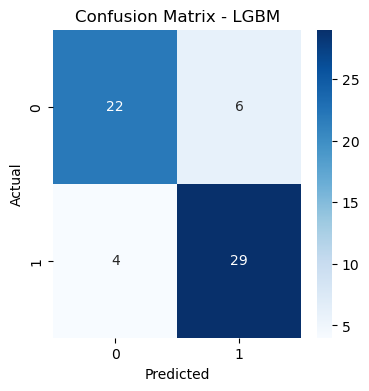

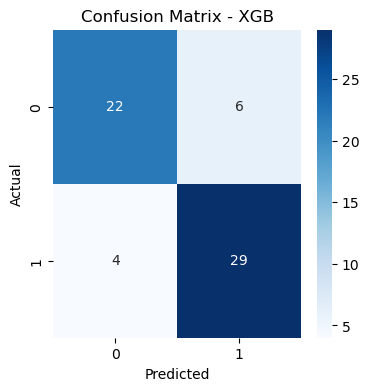

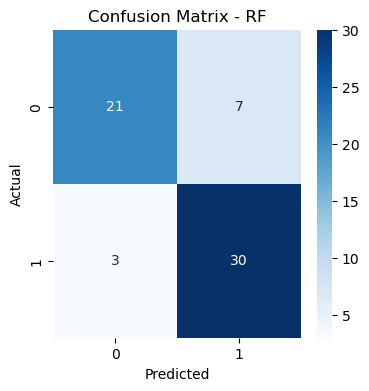

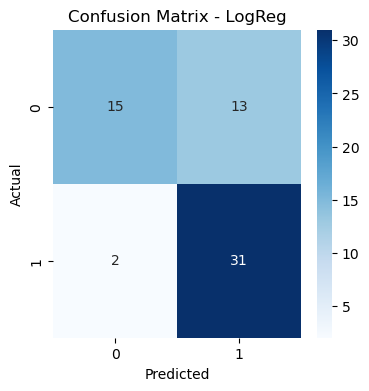

In [86]:
for name in predictions:
    cm = confusion_matrix(y_test, predictions[name]["y_pred"])

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## ROC

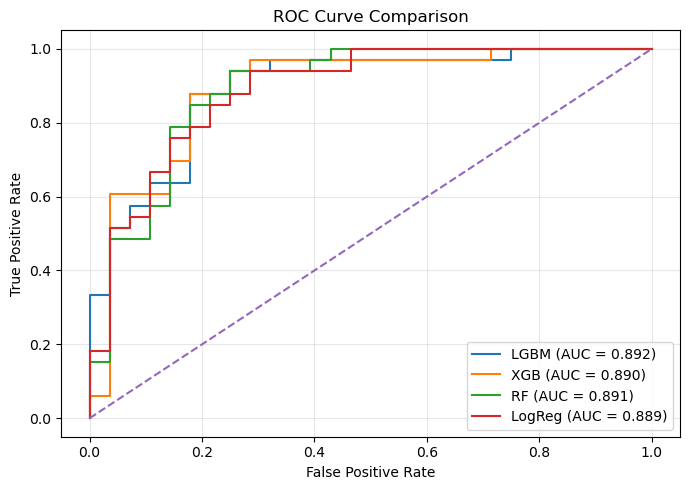

In [87]:
plt.figure(figsize=(7, 5))

for name in predictions:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]["y_prob"])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusion

In [90]:
pkl.dump(model_lgbm, open('best_model.pkl', 'wb'))

In [91]:
model_lgbm.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 0.7516967431077703,
 'importance_type': 'split',
 'learning_rate': 0.0319067187566505,
 'max_depth': 11,
 'min_child_samples': 5,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 730,
 'n_jobs': None,
 'num_leaves': 244,
 'objective': 'binary',
 'random_state': 50303776,
 'reg_alpha': 0.008109218983074139,
 'reg_lambda': 0.030949457025478713,
 'subsample': 0.6604675555847034,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}